# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-26: UBFC-Phys evaluation review — shared-miss windows

### What we are testing
In 7.4% of T1 primary windows, PhysNet v2 and POS agree within 5 bpm while both miss the wrist reference by more than 20 bpm. Two explanations predict different evidence:

- **H1, reference failure:** the wrist Empatica E4 BVP is corrupted (wrist motion, poor contact) but still passes the reference gate. Expected: the camera frequency visible in the reference spectrum, amplitude bursts in the reference, and an erratic reference heart rate from window to window.
- **H2, shared camera failure:** both camera methods lock onto the same non-cardiac rhythm in the face video (illumination, motion, a harmonic). They share the input, so they can share the failure. Expected: a clean, smooth reference, with no reference frequency in the camera spectra.

### Why this matters
Under H1, the reference gate lets bad wrist data through and every UBFC-Phys figure is inflated by reference error. Under H2, these are real estimator failures, and the table understates nothing. No accuracy figure from `check_ubfc_phys` should be quoted until this is settled.

Only waveforms and spectra are plotted; no face frames are rendered.

In [1]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'app' / 'live_vitals').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from app.live_vitals import config
from app.live_vitals.estimators import registry
from app.live_vitals.signal.spectral import rgb_trace, pos

EVAL_DIR = REPO_ROOT / 'Data' / 'ubfc_phys_eval'
STORE = Path(r'D:\QualityPhys\phase 3 datasets\ubfc_phys_phase3_rc_none.h5')
AGREE_BPM = 5.0   # PhysNet and POS within this of each other: the two camera methods agree
MISS_BPM = 20.0   # both further than this from the reference: a shared miss
N_WORST = 5

cols = ['recording', 'task', 'start', 't_start_s', 'ref_hr', 'ref_confidence', 'ref_kept', 'primary', 'pred_hr']
physnet = pd.read_csv(EVAL_DIR / 'windows_hr_physnet_v2.csv', usecols=cols)
spectral = pd.read_csv(EVAL_DIR / 'windows_hr_spectral.csv', usecols=['recording', 'start', 'pred_hr'])
windows = (physnet.rename(columns={'pred_hr': 'hr_physnet'})
           .merge(spectral.rename(columns={'pred_hr': 'hr_pos'}), on=['recording', 'start']))
windows['err_physnet'] = windows.hr_physnet - windows.ref_hr
windows['err_pos'] = windows.hr_pos - windows.ref_hr
windows['camera_agree'] = (windows.hr_physnet - windows.hr_pos).abs() < AGREE_BPM
windows['shared_miss'] = (windows.primary & windows.camera_agree
                          & (windows.err_physnet.abs() > MISS_BPM)
                          & (windows.err_pos.abs() > MISS_BPM))
FPS = float(pd.read_csv(EVAL_DIR / 'recordings_hr_physnet_v2.csv', usecols=['fps']).fps.iloc[0])
WINDOW_S = config.CLIP_LEN / FPS

t1 = windows[(windows.task == 'T1') & windows.primary
             & windows.hr_physnet.notna() & windows.hr_pos.notna()]
per_recording = (t1.groupby('recording')
                 .agg(windows=('start', 'size'),
                      median_abs_err_physnet=('err_physnet', lambda e: e.abs().median()),
                      median_abs_err_pos=('err_pos', lambda e: e.abs().median()),
                      shared_miss_fraction=('shared_miss', 'mean'))
                 .sort_values('median_abs_err_physnet'))
worst = list(per_recording.index[-N_WORST:][::-1])

print(f'T1 primary windows scored by both: {len(t1)} | shared misses: {int(t1.shared_miss.sum())} '
      f'({t1.shared_miss.mean():.3f}) in {t1.loc[t1.shared_miss, "recording"].nunique()} recordings')
print(f'\nworst {N_WORST} T1 recordings by PhysNet median |error|:')
print(per_recording.loc[worst].round(3).to_string())
print(f'\nacross all {len(per_recording)} T1 recordings, median per-recording median |error|: '
      f'PhysNet {per_recording.median_abs_err_physnet.median():.2f}, '
      f'POS {per_recording.median_abs_err_pos.median():.2f}')

T1 primary windows scored by both: 3474 | shared misses: 256 (0.074) in 22 recordings

worst 5 T1 recordings by PhysNet median |error|:
           windows  median_abs_err_physnet  median_abs_err_pos  shared_miss_fraction
recording                                                                           
s33_T1          47                  35.785              35.762                 0.872
s8_T1           78                  29.917              29.927                 0.718
s52_T1          63                  20.578              20.329                 0.508
s53_T1          67                  17.942              19.188                 0.433
s1_T1           75                  16.517              16.561                 0.320

across all 54 T1 recordings, median per-recording median |error|: PhysNet 2.96, POS 3.18


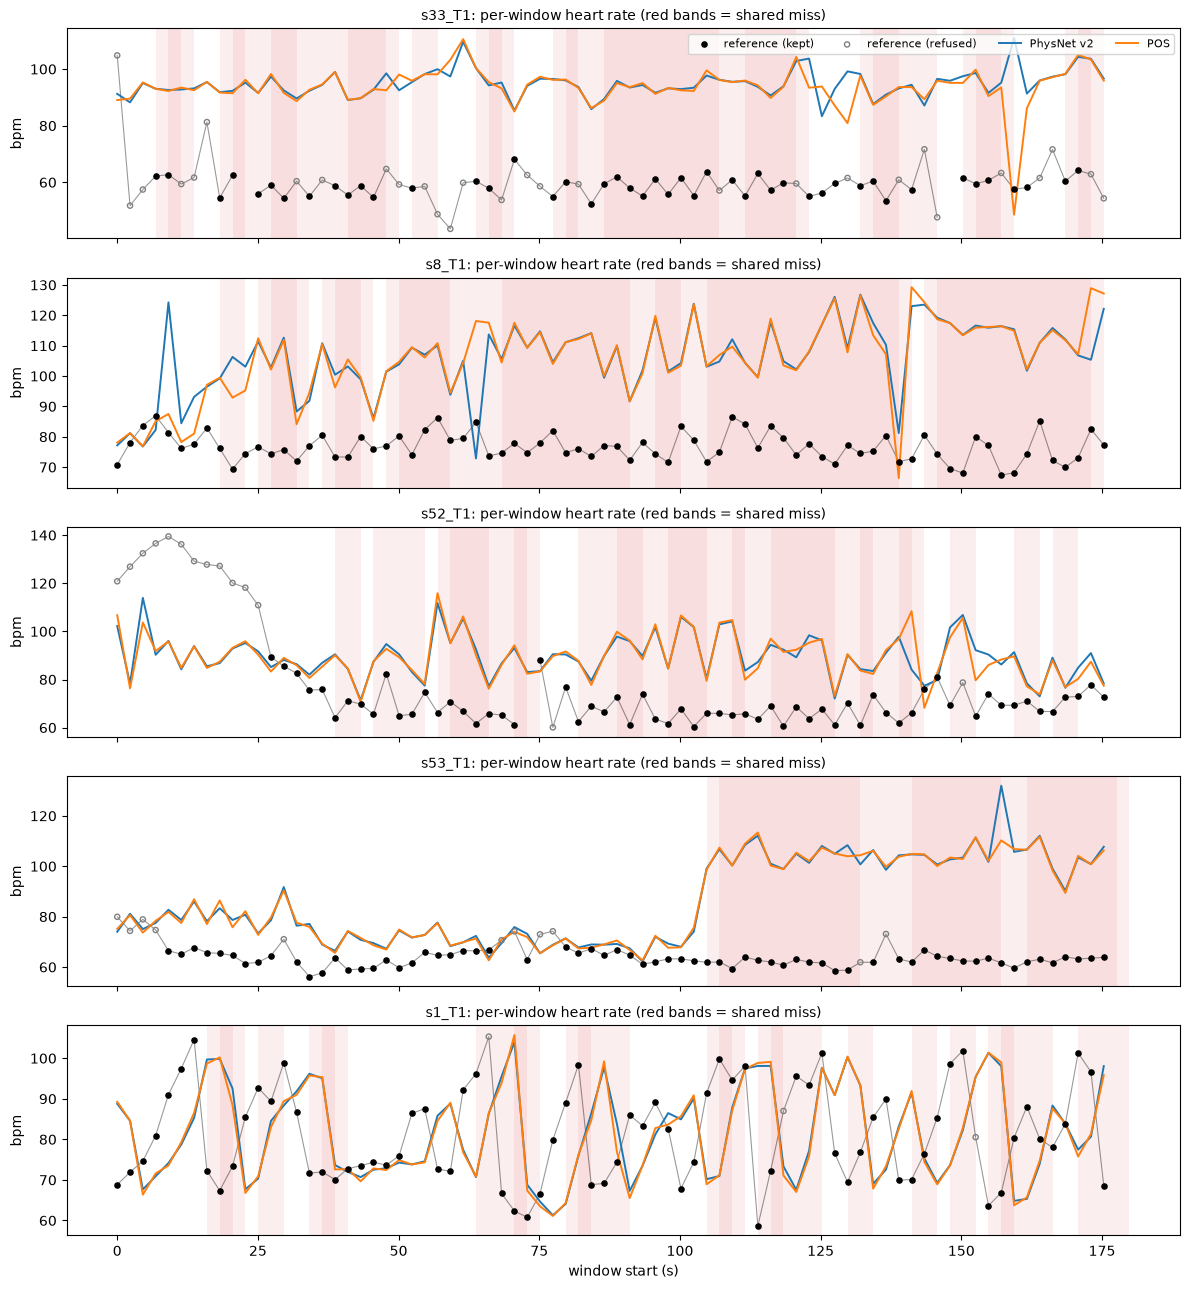

In [2]:
fig, axes = plt.subplots(N_WORST, 1, figsize=(12, 2.6 * N_WORST), sharex=True)
for ax, rec in zip(np.atleast_1d(axes), worst):
    r = windows[windows.recording == rec].sort_values('start')
    for t in r.loc[r.shared_miss, 't_start_s']:
        ax.axvspan(t, t + WINDOW_S, color='tab:red', alpha=0.08, lw=0)
    ax.plot(r.t_start_s, r.ref_hr, color='black', lw=0.8, alpha=0.4)
    ax.scatter(r.loc[r.ref_kept, 't_start_s'], r.loc[r.ref_kept, 'ref_hr'], s=14,
               color='black', label='reference (kept)', zorder=3)
    ax.scatter(r.loc[~r.ref_kept, 't_start_s'], r.loc[~r.ref_kept, 'ref_hr'], s=14,
               facecolors='none', edgecolors='grey', label='reference (refused)', zorder=3)
    ax.plot(r.t_start_s, r.hr_physnet, color='tab:blue', lw=1.4, label='PhysNet v2')
    ax.plot(r.t_start_s, r.hr_pos, color='tab:orange', lw=1.4, label='POS')
    ax.set_ylabel('bpm')
    ax.set_title(f'{rec}: per-window heart rate (red bands = shared miss)', fontsize=10)
np.atleast_1d(axes)[0].legend(loc='upper right', fontsize=8, ncol=4)
np.atleast_1d(axes)[-1].set_xlabel('window start (s)')
plt.tight_layout()
fig.savefig(EVAL_DIR / 'review_timecourse_T1_worst.png', dpi=110)
plt.show()

In [4]:
def band_spectrum(x, fps):
    """Returns (bpm, power) over the cardiac band, zero-padded as in signal/hr.py."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n_fft = len(x) * config.FFT_PAD_FACTOR
    power = np.abs(np.fft.rfft(x * np.hanning(len(x)), n=n_fft)) ** 2
    freqs = np.fft.rfftfreq(n_fft, 1.0 / fps)
    band = (freqs >= config.HR_LOW_HZ) & (freqs <= config.HR_HIGH_HZ)
    return freqs[band] * 60.0, power[band]


def relative_power_at(bpm, power, target_bpm, half_width_bpm=config.CONFIDENCE_FLOOR_HZ * 60.0):
    """Largest in-band power within half_width_bpm of a target, relative to the spectrum's peak."""
    near = np.abs(bpm - target_bpm) <= half_width_bpm
    return float(power[near].max() / power.max()) if near.any() and power.max() > 0 else np.nan


rows, pos_signals = [], {}
with h5py.File(STORE, 'r') as store:
    for rec in worst:
        bvp = store[rec]['bvp'][()]
        pos_signals[rec] = pos(rgb_trace(store[rec]['frames'][()]), FPS)
        r = windows[(windows.recording == rec) & windows.primary
                    & windows.hr_physnet.notna() & windows.hr_pos.notna()].sort_values('start')
        stds = [np.std(bvp[s:s + config.CLIP_LEN]) for s in r.start]
        median_std = np.median(stds)
        for (_, w), sd in zip(r.iterrows(), stds):
            s = int(w.start)
            camera_bpm = (w.hr_physnet + w.hr_pos) / 2.0
            ref_bpm_axis, ref_power = band_spectrum(bvp[s:s + config.CLIP_LEN], FPS)
            pos_bpm_axis, pos_power = band_spectrum(pos_signals[rec][s:s + config.CLIP_LEN], FPS)
            rows.append(dict(recording=rec, shared_miss=w.shared_miss,
                             ref_power_at_camera_hr=relative_power_at(ref_bpm_axis, ref_power, camera_bpm),
                             pos_power_at_reference_hr=relative_power_at(pos_bpm_axis, pos_power, w.ref_hr),
                             ref_amplitude_ratio=sd / median_std))
spectral_checks = pd.DataFrame(rows)

summary = (spectral_checks.groupby(['recording', 'shared_miss'])
           .agg(windows=('ref_amplitude_ratio', 'size'),
                ref_power_at_camera_hr=('ref_power_at_camera_hr', 'median'),
                pos_power_at_reference_hr=('pos_power_at_reference_hr', 'median'),
                ref_amplitude_ratio=('ref_amplitude_ratio', 'median'),
                ref_amplitude_over_2x=('ref_amplitude_ratio', lambda a: (a > 2).mean())))
print('medians per recording, shared-miss windows (True) against the other primary windows (False):')
print(summary.round(3).to_string())


def median_step(series):
    """Median absolute change between consecutive windows, in bpm."""
    return float(np.median(np.abs(np.diff(series.to_numpy()))))


continuity = []
for rec in worst:
    r = windows[(windows.recording == rec) & windows.primary
                & windows.hr_physnet.notna() & windows.hr_pos.notna()].sort_values('start')
    consecutive = np.diff(r.start.to_numpy()) == config.WINDOW_STRIDE
    if consecutive.sum() < 3:
        continue
    continuity.append(dict(recording=rec,
                           reference=median_step(r.ref_hr), physnet=median_step(r.hr_physnet),
                           pos=median_step(r.hr_pos)))
print('\nmedian |HR change| between consecutive primary windows (bpm, 2.28 s apart):')
print(pd.DataFrame(continuity).set_index('recording').round(2).to_string())

medians per recording, shared-miss windows (True) against the other primary windows (False):
                       windows  ref_power_at_camera_hr  pos_power_at_reference_hr  ref_amplitude_ratio  ref_amplitude_over_2x
recording shared_miss                                                                                                        
s1_T1     False             51                   0.892                      0.935                1.000                  0.000
          True              24                   0.105                      0.089                0.998                  0.000
s33_T1    False              6                   0.143                      0.405                1.032                  0.167
          True              41                   0.077                      0.062                1.000                  0.000
s52_T1    False             31                   0.983                      1.000                1.016                  0.000
          True           

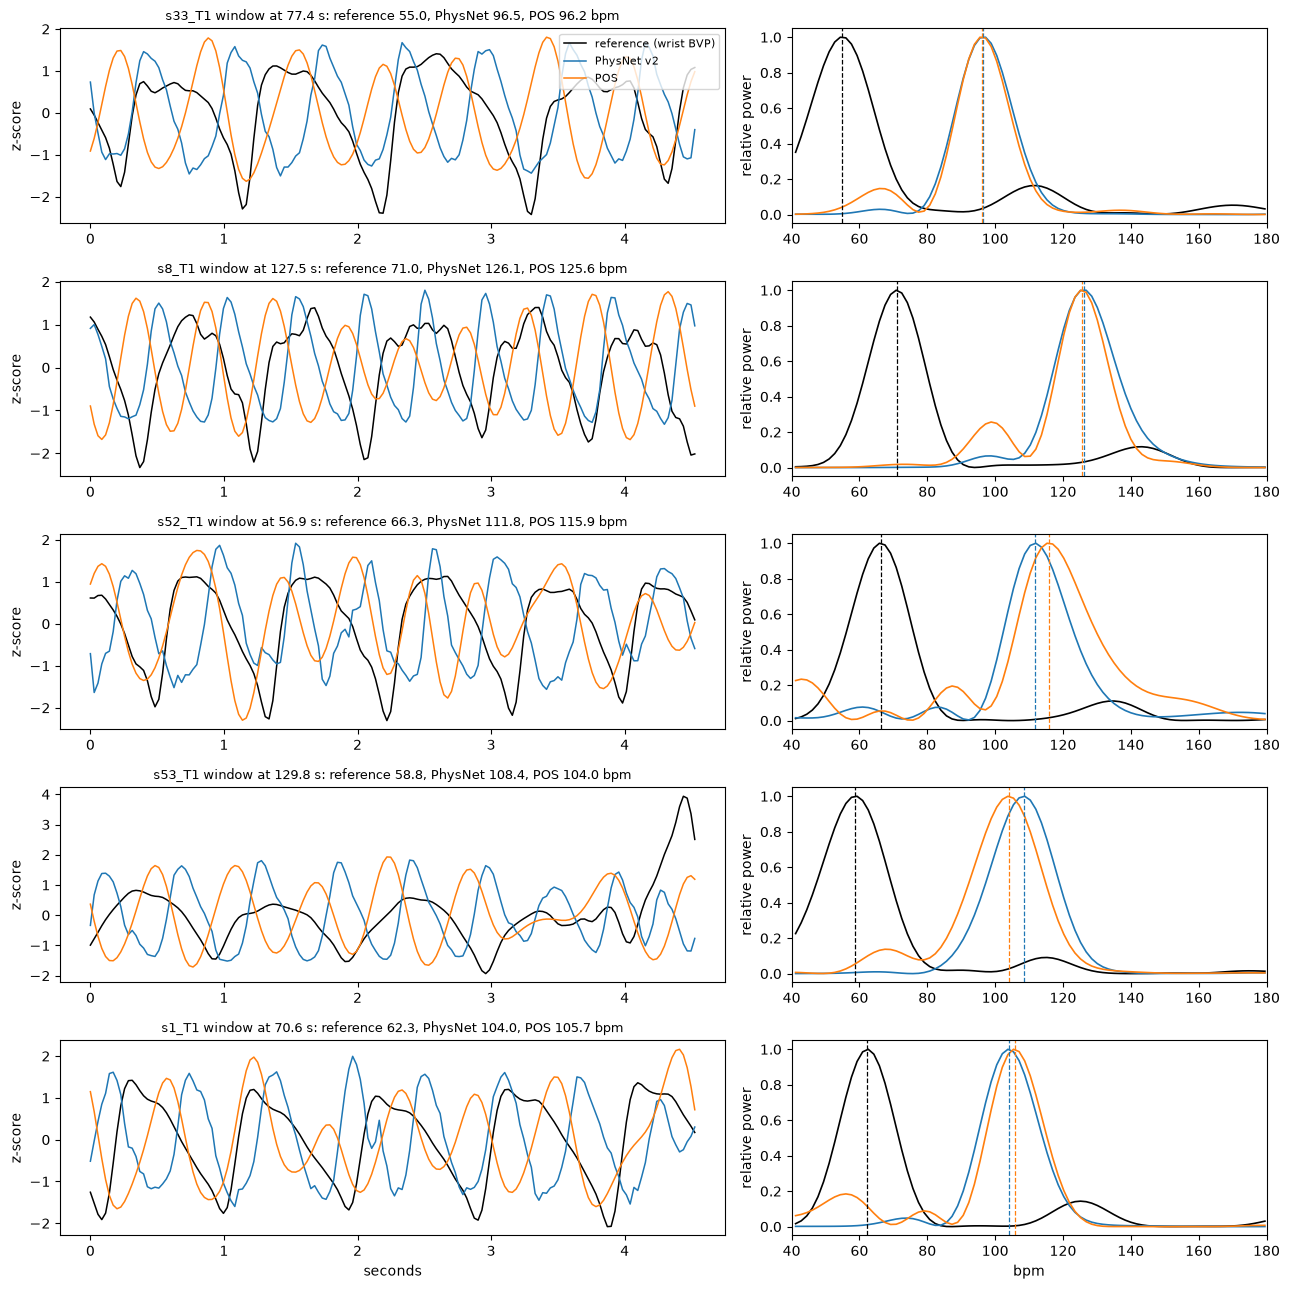

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
physnet_estimator = registry.get_estimator('hr_physnet_v2', device=device)

fig, axes = plt.subplots(N_WORST, 2, figsize=(13, 2.6 * N_WORST),
                         gridspec_kw=dict(width_ratios=[1.4, 1]))
with h5py.File(STORE, 'r') as store:
    for row_axes, rec in zip(np.atleast_2d(axes), worst):
        r = windows[(windows.recording == rec) & windows.primary & windows.hr_physnet.notna()]
        pick = r[r.shared_miss] if r.shared_miss.any() else r
        w = pick.loc[pick.err_physnet.abs().idxmax()]
        s = int(w.start)
        frames = store[rec]['frames'][s:s + config.CLIP_LEN]
        reference = store[rec]['bvp'][s:s + config.CLIP_LEN]
        physnet_wave = physnet_estimator.estimate(frames, FPS).waveform
        signals = {'reference (wrist BVP)': (reference, 'black'),
                   'PhysNet v2': (physnet_wave, 'tab:blue'),
                   'POS': (pos_signals[rec][s:s + config.CLIP_LEN], 'tab:orange')}
        t = np.arange(config.CLIP_LEN) / FPS
        for label, (x, colour) in signals.items():
            if x is None:
                continue
            z = (x - np.mean(x)) / (np.std(x) + 1e-12)
            row_axes[0].plot(t, z, color=colour, lw=1.1, label=label)
            bpm_axis, power = band_spectrum(x, FPS)
            row_axes[1].plot(bpm_axis, power / power.max(), color=colour, lw=1.2, label=label)
        for value, colour in ((w.ref_hr, 'black'), (w.hr_physnet, 'tab:blue'), (w.hr_pos, 'tab:orange')):
            row_axes[1].axvline(value, color=colour, ls='--', lw=0.9)
        row_axes[0].set_title(f'{rec} window at {w.t_start_s:.1f} s: reference {w.ref_hr:.1f}, '
                              f'PhysNet {w.hr_physnet:.1f}, POS {w.hr_pos:.1f} bpm', fontsize=9)
        row_axes[0].set_ylabel('z-score')
        row_axes[1].set_xlim(40, 180)
        row_axes[1].set_ylabel('relative power')
np.atleast_2d(axes)[0, 0].legend(fontsize=8, loc='upper right')
np.atleast_2d(axes)[-1, 0].set_xlabel('seconds')
np.atleast_2d(axes)[-1, 1].set_xlabel('bpm')
plt.tight_layout()
fig.savefig(EVAL_DIR / 'review_spectra_T1_worst.png', dpi=110)
plt.show()

### Follow-up: swapped reference files and timing offsets

**What we are testing**
- **H3, swapped reference:** in the recordings with shared misses, does the camera heart-rate series fit another recording's reference better than its own? UBFC-Phys has had packaging errors before (s40's T3 video, s56's anxiety file).
- **Timing offset:** does the camera series trail the reference by a fixed delay, as s1 suggests? And is one delay shared across the corpus?

**Why this matters**
A swapped file is a dataset error to document and exclude. A timing offset is a reference-alignment problem that inflates window errors whenever heart rate changes. If neither holds for a recording, what remains points to a failure in the camera estimates.

**Not included: a non-skin region test for H2.** Crop border, crop corners and raw-frame wall corners all failed the control (high POS power at the reference HR where camera and reference agree), because POS normalises a featureless patch into band-limited noise. A valid version needs an absolute signal-to-noise measure with a noise baseline.

In [6]:
MIN_OVERLAP = 20  # windows both series must share to score a candidate reference

windows['hr_camera'] = windows[['hr_physnet', 'hr_pos']].mean(axis=1, skipna=False)
by_recording = {rec: g.set_index('start').sort_index() for rec, g in windows.groupby('recording')}
suspects = (windows[windows.shared_miss & (windows.task == 'T1')]
            .groupby('recording').size().sort_values(ascending=False).index.tolist())


def fit(camera, candidate):
    """Median |camera - reference| and Pearson r over windows both share, or None."""
    ref = candidate.ref_hr.where(candidate.ref_kept)
    joined = pd.concat([camera, ref], axis=1, keys=['camera', 'ref']).dropna()
    if len(joined) < MIN_OVERLAP:
        return None
    r = joined.camera.corr(joined.ref) if joined.camera.std() > 0 and joined.ref.std() > 0 else np.nan
    return float((joined.camera - joined.ref).abs().median()), float(r), len(joined)


swap_rows = []
for rec in suspects:
    camera = by_recording[rec].hr_camera
    subject = rec.split('_')[0]
    scores = {c: fit(camera, by_recording[c]) for c in by_recording}
    scores = {c: s for c, s in scores.items() if s is not None}
    own = scores.get(rec)
    others = {c: s for c, s in scores.items() if c != rec}
    best = min(others, key=lambda c: others[c][0])
    same_subject = {c: s for c, s in others.items() if c.split('_')[0] == subject}
    best_same = min(same_subject, key=lambda c: same_subject[c][0]) if same_subject else None
    swap_rows.append(dict(
        recording=rec,
        shared_miss_windows=int(windows[(windows.recording == rec) & windows.shared_miss].shape[0]),
        own_median_err=own[0] if own else np.nan, own_r=own[1] if own else np.nan,
        best_other=best, best_median_err=others[best][0], best_r=others[best][1],
        others_within_5bpm=sum(s[0] < 5 for s in others.values()),
        own_rank=1 + sum(s[0] < own[0] for s in others.values()) if own else np.nan,
        best_same_subject=best_same,
        same_subject_median_err=same_subject[best_same][0] if best_same else np.nan))
swap = pd.DataFrame(swap_rows).set_index('recording')
print(f'{len(suspects)} T1 recordings with shared misses; candidates are all '
      f'{len(by_recording)} recordings\' kept reference windows (zero lag):')
print(swap.round(2).to_string())

22 T1 recordings with shared misses; candidates are all 168 recordings' kept reference windows (zero lag):
           shared_miss_windows  own_median_err  own_r best_other  best_median_err  best_r  others_within_5bpm  own_rank best_same_subject  same_subject_median_err
recording                                                                                                                                                         
s8_T1                       56           30.21  -0.10     s28_T3             6.54    0.28                   0        82             s8_T2                    33.89
s33_T1                      41           35.57   0.17     s18_T1             2.45    0.13                  13       127            s33_T2                    30.48
s52_T1                      32           21.20  -0.24      s6_T1             5.01    0.09                   0       109            s52_T3                    13.75
s53_T1                      29           18.75  -0.22     s24_T3             7

camera HR against reference HR at lags of -10..+10 windows (positive = camera trails reference; one window = 2.28 s):
           r_lag0  err_lag0  best_lag_windows  best_lag_s  r_best  err_best
recording                                                                  
s8_T1       -0.10     30.21                -9       -20.5    0.20     28.58
s33_T1      -0.07     35.21                -5       -11.4    0.08     35.24
s52_T1       0.07     22.50                -8       -18.2    0.16     21.26
s53_T1      -0.28     15.17               -10       -22.8   -0.18     13.16
s1_T1       -0.34     16.73                 2         4.6    0.90      2.02
s32_T1      -0.17     13.11                -9       -20.5    0.25     11.13
s9_T1        0.11     14.12                -7       -15.9    0.21     17.01
s30_T1      -0.13     13.41                 3         6.8    0.31     15.11
s40_T1       0.12     13.33                -7       -15.9    0.19     12.96
s38_T1       0.22      7.51                -1 

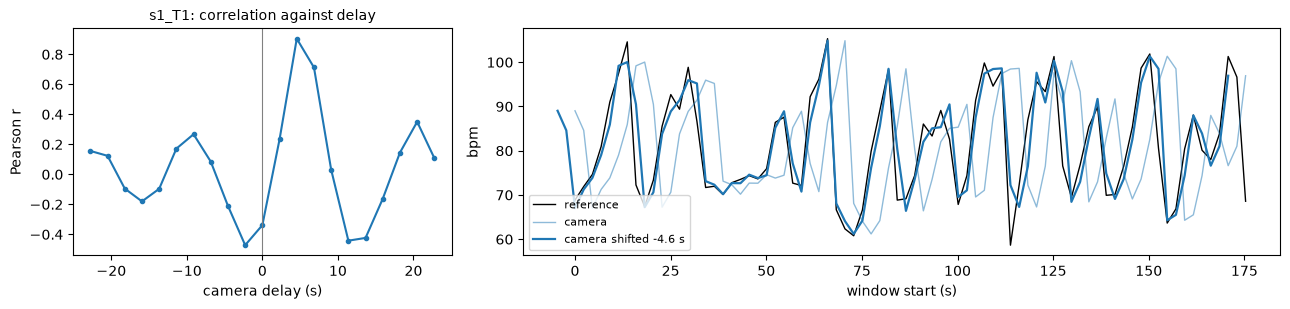

In [7]:
MAX_LAG = 10  # windows; one step is WINDOW_STRIDE / FPS = 2.28 s
STEP_S = config.WINDOW_STRIDE / FPS


def lagged(camera, reference, lag):
    """Pearson r and median |diff| pairing reference[k] with camera[k + lag]."""
    n = len(camera)
    if lag >= 0:
        c, ref = camera[lag:], reference[:n - lag]
    else:
        c, ref = camera[:n + lag], reference[-lag:]
    ok = np.isfinite(c) & np.isfinite(ref)
    if ok.sum() < MIN_OVERLAP or c[ok].std() == 0 or ref[ok].std() == 0:
        return np.nan, np.nan
    return float(np.corrcoef(c[ok], ref[ok])[0, 1]), float(np.median(np.abs(c[ok] - ref[ok])))


lag_rows, lag_curves = [], {}
for rec in suspects:
    g = by_recording[rec]
    camera, reference = g.hr_camera.to_numpy(), g.ref_hr.to_numpy()
    curve = {lag: lagged(camera, reference, lag) for lag in range(-MAX_LAG, MAX_LAG + 1)}
    lag_curves[rec] = curve
    finite = {lag: v for lag, v in curve.items() if np.isfinite(v[0])}
    best = max(finite, key=lambda lag: finite[lag][0])
    lag_rows.append(dict(recording=rec, r_lag0=curve[0][0], err_lag0=curve[0][1],
                         best_lag_windows=best, best_lag_s=round(best * STEP_S, 1),
                         r_best=finite[best][0], err_best=finite[best][1]))
lags = pd.DataFrame(lag_rows).set_index('recording')
print(f'camera HR against reference HR at lags of -{MAX_LAG}..+{MAX_LAG} windows '
      f'(positive = camera trails reference; one window = {STEP_S:.2f} s):')
print(lags.round(2).to_string())

# Corpus-wide: is there one delay shared by every recording? A delay is only measurable where
# heart rate actually varies, so recordings with a flat reference are left out, and only
# lags that clearly beat zero lag are counted.
MIN_REF_SD = 4.0     # bpm; below this the HR series is too flat to time
CLEAR_R = 0.6        # a lag counts only if its correlation reaches this
corpus_rows = []
for rec, g in by_recording.items():
    camera, reference = g.hr_camera.to_numpy(), g.ref_hr.where(g.ref_kept).to_numpy()
    if np.nanstd(reference) < MIN_REF_SD:
        continue
    curve = {lag: lagged(camera, reference, lag)[0] for lag in range(-MAX_LAG, MAX_LAG + 1)}
    finite = {lag: r for lag, r in curve.items() if np.isfinite(r)}
    if not finite:
        continue
    best = max(finite, key=finite.get)
    corpus_rows.append(dict(recording=rec, task=rec.split('_')[1], best_lag=best,
                            r_best=finite[best], r_lag0=curve[0]))
corpus = pd.DataFrame(corpus_rows)
clear = corpus[corpus.r_best >= CLEAR_R]
print(f'\n{len(corpus)} recordings with a varying reference (SD >= {MIN_REF_SD} bpm); '
      f'{len(clear)} have a lag with r >= {CLEAR_R}. Their best lags:')
print(clear.groupby('best_lag').agg(recordings=('recording', 'size'),
                                    median_r_best=('r_best', 'median'),
                                    median_r_lag0=('r_lag0', 'median'))
      .rename(index=lambda lag: f'{lag:+d} ({lag * STEP_S:+.1f} s)').round(2).to_string())
print('\nbest lag counts by task:', {task: {int(k): int(v) for k, v in g.best_lag.value_counts().items()}
                                    for task, g in clear.groupby('task')})

LAG_REC = 's1_T1'
fig, (ax_curve, ax_series) = plt.subplots(1, 2, figsize=(13, 3.2), gridspec_kw=dict(width_ratios=[1, 2]))
curve = lag_curves[LAG_REC]
ax_curve.plot([lag * STEP_S for lag in curve], [v[0] for v in curve.values()], marker='o', ms=3)
ax_curve.axvline(0, color='grey', lw=0.8)
ax_curve.set_xlabel('camera delay (s)')
ax_curve.set_ylabel('Pearson r')
ax_curve.set_title(f'{LAG_REC}: correlation against delay', fontsize=10)
g = by_recording[LAG_REC]
best = int(lags.loc[LAG_REC, 'best_lag_windows'])
ax_series.plot(g.t_start_s, g.ref_hr, color='black', lw=1, label='reference')
ax_series.plot(g.t_start_s, g.hr_camera, color='tab:blue', lw=1, alpha=0.5, label='camera')
ax_series.plot(g.t_start_s - best * STEP_S, g.hr_camera, color='tab:blue', lw=1.6,
               label=f'camera shifted {-best * STEP_S:+.1f} s')
ax_series.set_xlabel('window start (s)')
ax_series.set_ylabel('bpm')
ax_series.legend(fontsize=8)
plt.tight_layout()
fig.savefig(EVAL_DIR / 'review_lag_s1.png', dpi=110)
plt.show()

### Conclusions: shared-miss review (2026-09-15)

**Question.** In 7.4% of T1 primary windows (256 of 3,474, in 22 recordings), PhysNet v2 and POS agree within 5 bpm while both miss the wrist reference by more than 20 bpm. Is the reference wrong, or are the camera estimates?

**1. The reference gate is not letting bad wrist data through** (the 5 worst recordings, s33, s8, s52, s53 and s1, were examined in cells 3–5). In their shared-miss windows the reference shows:
- no amplitude bursts (median amplitude ratio about 1.0, no window above 2×)
- a pulse-like waveform
- window-to-window changes no larger than the camera estimates' (1.5–6.8 vs 3.4–9.1 bpm per step)

The reference and camera spectra are disjoint. The camera heart rate carries 0.02–0.11 of peak power in the reference spectrum, and the reference heart rate carries 0.05–0.27 in the POS spectrum.

**2. No reference file is swapped** (all 22 recordings, cell 7). No other reference among the 168 fits the camera series convincingly (best alternatives reach at most r = 0.43). Where the camera estimate works, a recording's own reference ranks first, so the test would have detected a swap. Only references inside UBFC-Phys were searched.

**3. Some recordings have a timing offset between video and reference** (cell 8).
- s1_T1, s25_T1 and s27_T1 fit best with the camera series 4.6 s behind the reference. For s1, correlation goes from −0.34 to 0.90 and median error from 16.7 to 2.0 bpm.
- There is no single offset across the corpus. Of 27 recordings with a measurable delay, 9 fit best at zero lag and the rest scatter between −6.8 and +15.9 s.
- Offsets of several seconds are not physiological, so misaligned start times in the dataset are the likely cause. Shifts of one window (2.3 s) are near the resolution of this test.

**4. In s8_T1, s33_T1, s52_T1 and s53_T1 the camera estimates fail.** Their reference is clean, not swapped and not delayed. That leaves a shared failure of both camera methods — a conclusion reached by elimination, not observed directly.
- Both methods lock onto a component near 95–125 bpm that is not a clean harmonic of the heart rate (ratio about 1.7–1.8).
- In s53 camera and reference agree for about 100 s. The camera estimate then rises by 35–40 bpm within a few windows while the reference stays near 62 bpm.
- The cause is not identified.

**Method negative.** A test comparing the face centre with non-skin regions failed its control in every variant: the crop border, the crop corners, and the corners of the raw video frames (wall only). POS turns a featureless patch into band-limited noise, and power measured relative to a signal's own peak comes out high by chance. A valid version needs an absolute signal-to-noise measure with a noise baseline.

### Consequences
- **Cross-check agreement is not corroboration on this corpus.** PhysNet and POS read the same video, and in 7.4% of T1 windows they agree with each other and are both wrong. The app's POS cross-check cannot flag these failures. This belongs in the model card's limitations.
- **Report recording-level and window-level figures together.** A recording-level value (one per 180 s recording) is insensitive to timing offsets of a few seconds; window-level values are not.
- **Do not lag-correct.** The delay can only be estimated from the camera estimates themselves, so correcting it would favour them.
  - s1_T1, s25_T1 and s27_T1 are named as timing-offset recordings.
  - Any figure that excludes them is a sensitivity analysis decided after seeing the data, and is labelled as such.
- **Name the known failures:** s8_T1, s33_T1, s52_T1 and s53_T1 are camera failures of unknown cause.

### Figures for reporting
Primary analysis set; wrist Empatica E4 reference; 160-frame windows spanning 4.55 s at 35.138 fps (the model was trained on 5.33 s windows). Held-out and cross-dataset; research figures, not validated accuracy.

| task | estimator | window MAE (bpm) | recording MAE (bpm) | recordings reported |
|---|---|---:|---:|---:|
| T1 rest | PhysNet v2 | 6.97 | 3.93 | 54 / 54 |
| T1 rest | POS | 6.96 | 3.65 | 54 / 54 |
| T2 speech | PhysNet v2 | 22.26 | 12.95 | 27 / 33 |
| T2 speech | POS | 19.11 | 8.22 | 20 / 33 |
| T3 arithmetic | PhysNet v2 | 15.86 | 6.42 | 40 / 41 |
| T3 arithmetic | POS | 13.99 | 4.11 | 34 / 41 |

Recording MAE counts only the recordings for which the estimator reported a value. POS reports fewer T2 and T3 recordings, so its lower recording MAE there is partly a result of refusing harder recordings, and the two estimators are not directly comparable on that column. T1 is the quantitative result; T2 and T3 cover only their reference-accepted recordings and are read qualitatively.

### Still open
- Shared misses in T2 and T3 have not been reviewed.
- H1 was examined for 5 recordings; the swap and timing tests covered the 22 T1 recordings with shared misses.
- The cause of the camera failures (backlog: a region test with a noise baseline).
- A sensitivity analysis without the timing-offset recordings has not been computed.